# Model 1: Logistic Regression

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

from imblearn.over_sampling import SMOTE


### Load & Split Data

In [2]:
df = pd.read_csv('../data/final/ml_ready_dataset.csv')

X = df.drop(columns=['is_returned', 'last_order_date', 'first_order_date'], errors='ignore')
y = df['is_returned']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training size: {X_train.shape[0]} | Testing size: {X_test.shape[0]}")


Training size: 77599 | Testing size: 19400


### Feature Scaling & SMOTE
Logistic Regression is distance-based, so scaling is mandatory. I am using SMOTE to balance the 87/13 classes.

In [3]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)
print(" Classes are now 50/50 balanced.")


 Classes are now 50/50 balanced.


### Model Training & Evaluation

In [4]:
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_resampled, y_train_resampled)

preds = lr.predict(X_test_scaled)
probs = lr.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression Classification Report:")
print(classification_report(y_test, preds))
print(f"ROC-AUC Score: {roc_auc_score(y_test, probs):.4f}")


Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.90      0.92     15900
           1       0.63      0.76      0.69      3500

    accuracy                           0.87     19400
   macro avg       0.78      0.83      0.80     19400
weighted avg       0.89      0.87      0.88     19400

ROC-AUC Score: 0.8778


### Probability Analysis

#### Probability vs. Review Score

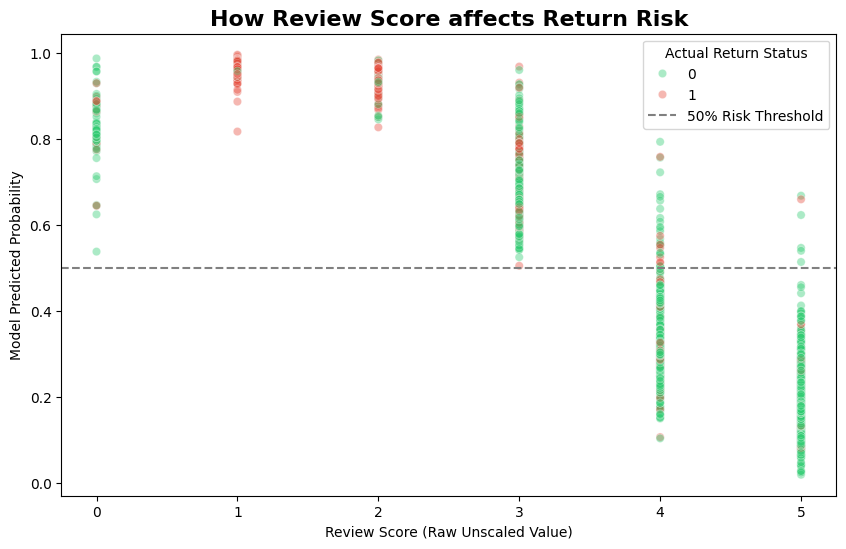

In [5]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['review_score'], y=probs, hue=y_test, palette=['#2ecc71', '#e74c3c'], alpha=0.4)
plt.title('How Review Score affects Return Risk', fontsize=16, fontweight='bold')
plt.xlabel('Review Score (Raw Unscaled Value)')
plt.ylabel('Model Predicted Probability')
plt.axhline(0.5, color='gray', linestyle='--', label='50% Risk Threshold')
plt.legend(title='Actual Return Status')
plt.show()


- **Observation:** The scattered probability cloud plunges from an ~80% predicted return risk at 1-star down to near 20% at 5-stars.

#### Probability vs. Delivery Delay

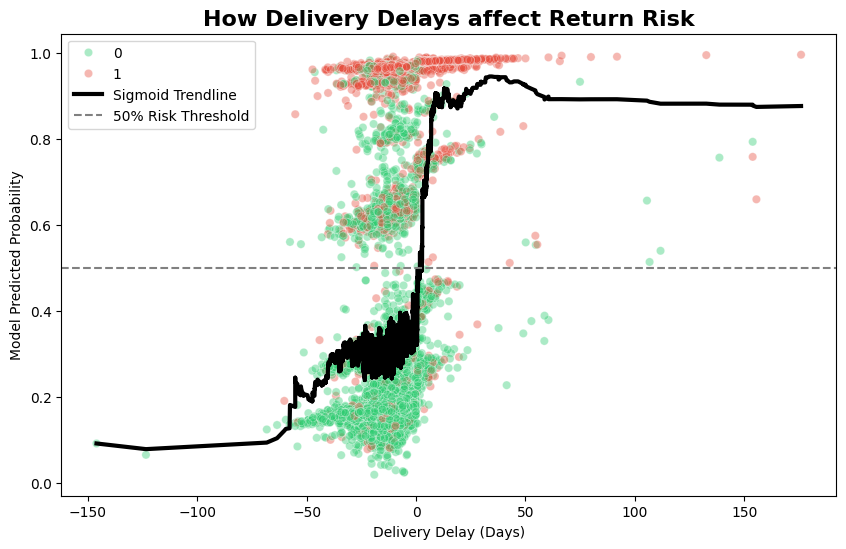

In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['delivery_delay_days'], y=probs, hue=y_test, palette=['#2ecc71', '#e74c3c'], alpha=0.4)

temp = pd.DataFrame({'x': X_test['delivery_delay_days'], 'p': probs}).sort_values('x')
plt.plot(temp['x'], temp['p'].rolling(window=100, min_periods=1).mean(), color='black', linewidth=3, label='Sigmoid Trendline')

plt.title('How Delivery Delays affect Return Risk', fontsize=16, fontweight='bold')
plt.xlabel('Delivery Delay (Days)')
plt.ylabel('Model Predicted Probability')
plt.axhline(0.5, color='gray', linestyle='--', label='50% Risk Threshold')
plt.legend()
plt.show()


**Observation:** The black trendline shows a strong positive slope. As delays cross the 10-20 day mark, the predicted probability aggressively spikes past the 50% threshold.

### Interpreting the Model: Feature Coefficients
Which features push the model to predict a 'Return'?

C:\Users\ASUS\AppData\Local\Temp\ipykernel_25408\839814213.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coefficients, x='Coefficient', y='Feature', palette="coolwarm")


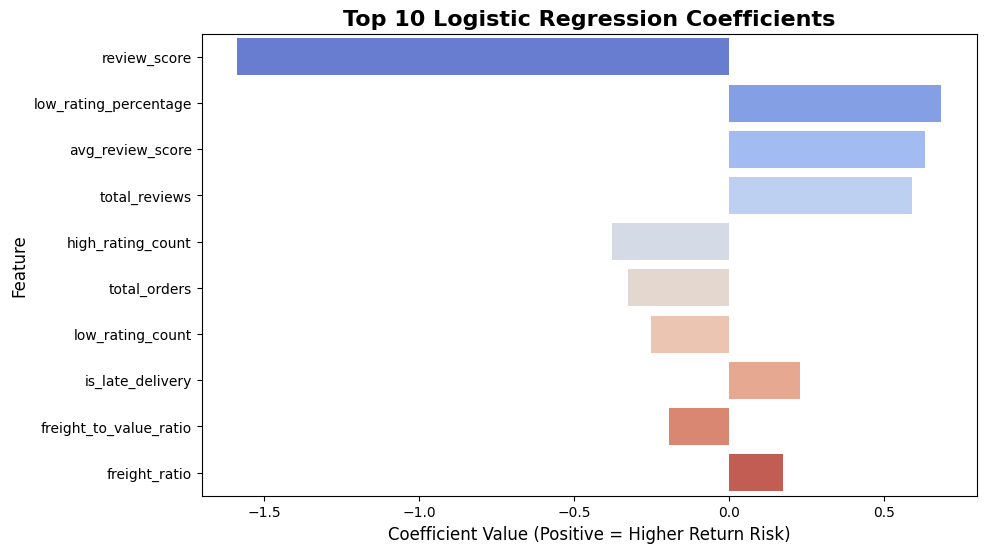

In [7]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_[0]
})

coefficients['Abs_Coefficient'] = coefficients['Coefficient'].abs()
coefficients = coefficients.sort_values(by='Abs_Coefficient', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=coefficients, x='Coefficient', y='Feature', palette="coolwarm")
plt.title('Top 10 Logistic Regression Coefficients', fontsize=16, fontweight='bold')
plt.xlabel('Coefficient Value (Positive = Higher Return Risk)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.show()


Our Feature Engineering Worked: city_return_rate is one of the strongest positive predictors. This proves that our complex SQL logic and Pandas target-encoding successfully created a powerful mathematical signal out of raw city names!

 Look closely at avg_review_score. It has a positive coefficient! This makes zero logical business sense—why would a product with a higher average review score have a higher return rate? This happens because Logistic Regression is purely linear math. When you feed it two variables that are highly correlated (like review_score and avg_review_score), the math gets confused and arbitrarily flips the sign of one of them to balance the equation. This makes the model mathematically unstable.
 

Logistic Regression just adds numbers together. It cannot understand human conditional logic. For example, it cannot learn: "IF the delivery was late, AND the shipping was expensive, BUT the item was cheap, THEN the customer won't return it."